In [16]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Setup

In [17]:
import os, sys
sys.path.append(os.path.dirname(os.getcwd())) # Add the parent directory to sys.path
sys.path.append('/Users/dhei/ai2/new-evals/olmo-repos/olmo/scripts') # Add the parent directory to sys.path

import pandas as pd
import numpy as np

from utils import DATA_DIR
from dataloader import get_nd_array, get_slice

from download.weka import pull_predictions_from_weka

In [18]:
pull_predictions_from_weka("aws")

File already exists and matches size: /Users/dhei/ai2/new-evals/analysis/data/all_aws_predictions.parquet


In [19]:
COLS = ['step', 'model', 'task', 'mix', 'size', 'token_ratio', 'native_id', 'acc_per_char']
df = pd.read_parquet(f'{DATA_DIR}/all_consistent_ranking_predictions.parquet', columns=COLS)
print(f'Loaded {len(df):,} instance predictions')

Loaded 114,524,590 instance predictions


In [ ]:
from utils.constants_tasks import RC_TASKS_OLMES

TASKS  = df.index.get_level_values('task').unique().to_list()

# Get task suites
OLMES = [task.split('::')[0].replace(':rc', '') for task in RC_TASKS_OLMES if 'mmlu_' not in task]
MMLU  = [t for t in TASKS if 'mmlu' in t]

MODELS = df.index.get_level_values('model').unique().to_list()

print(MODELS)

['prox_fineweb_pro-150M-5xC', 'dolma17-75p-DCLM-baseline-25p-530M-5xC', 'dolma-v1-6-and-sources-baseline-750M-5xC', 'fineweb_edu_dedup-300M-5xC', 'fineweb_edu_dedup-1B-5xC', 'falcon-750M-5xC', 'falcon_and_cc_tulu_qc_top10-300M-5xC', 'fineweb_edu_dedup-750M-5xC', 'falcon-150M-5xC', 'no_math_no_code-1B-5xC', 'no_reddit-530M-5xC', 'redpajama-300M-5xC', 'falcon_and_cc-750M-5xC', 'no_code-750M-5xC', 'no_math_no_code-150M-5xC', 'falcon_and_cc_tulu_qc_top10-150M-5xC', 'falcon_and_cc-1B-5xC', 'dolma17-25p-DCLM-baseline-75p-530M-5xC', 'c4-750M-5xC', 'dolma17-25p-DCLM-baseline-75p-300M-5xC', 'falcon_and_cc_og_eli5_oh_top10p-1B-5xC', 'dolma17-50p-DCLM-baseline-50p-300M-5xC', 'DCLM-baseline-750M-5xC', 'no_flan-150M-5xC', 'baseline-300M-5xC', 'falcon_and_cc_og_eli5_oh_top10p-300M-5xC', 'dolma-v1-6-and-sources-baseline-150M-5xC', 'falcon_and_cc_eli5_oh_top10p-300M-5xC', 'falcon_and_cc_eli5_oh_top20p-300M-5xC', 'falcon_and_cc_og_eli5_oh_top10p-530M-5xC', 'falcon_and_cc_eli5_oh_top20p-530M-5xC', 'falc

### Sample Variance

For $n$ samples with accuracy $\hat{p}$:

$SE = \sqrt{\frac{\hat{p}(1 - \hat{p})}{n}}$

In [188]:
_MODELS = [
    "prox_fineweb_pro-1B-5xC",
    "fineweb_edu_dedup-1B-5xC",
    "DCLM-baseline-1B-5xC",
    "c4-1B-5xC",
    "dolma17-50p-DCLM-baseline-50p-1B-5xC",
    "falcon_and_cc_tulu_qc_top10-1B-5xC",
    "falcon_and_cc_og_eli5_oh_top10p-1B-5xC",
]

In [189]:
def calculate_standard_error(avg_score, num_scores):
    """ https://arxiv.org/pdf/2411.00640#page=2.55 """
    return np.sqrt((avg_score * (1 - avg_score)) / num_scores)

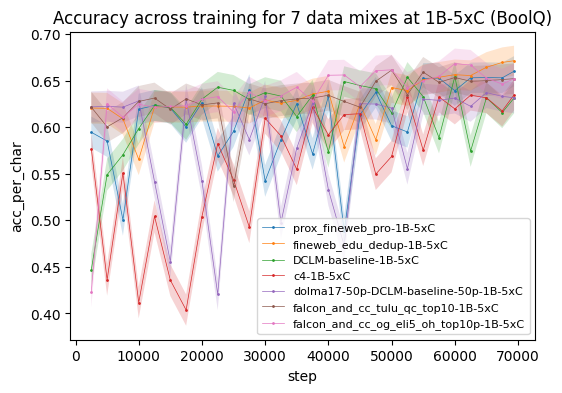

In [ ]:
import matplotlib.pyplot as plt

metric='acc_per_char'
task = 'boolq'

fig, axes = plt.subplots(1, 1, figsize=(6, 4), squeeze=False)
ax = axes[0][0]

for model in _MODELS:
    step, scores = get_nd_array(df, 'step', metric, model=model, task=task)
    num_scores = scores.shape[1]
    acc = scores.mean(axis=1)

    step, acc = step[1:], acc[1:]
    ci = 1.96 * calculate_standard_error(acc, num_scores)

    ax.fill_between(step, acc - ci, acc + ci, alpha=0.2)
    ax.plot(step, acc, label=model, linewidth=0.5, marker='.', markersize=2)

ax.legend(fontsize=8)
ax.set_xlabel('step')
ax.set_ylabel('acc_per_char')
ax.set_title(f'Accuracy across training for {len(_MODELS)} data mixes at 1B-5xC (BoolQ)')

plt.show()

### Accounting for Agreement Rate

Comparison of metric scores is about the same ~+0.16 vs ~+0.02, but the agreement rate is different:
Example of agreement between models (https://huggingface.co/spaces/allenai/model-diff):


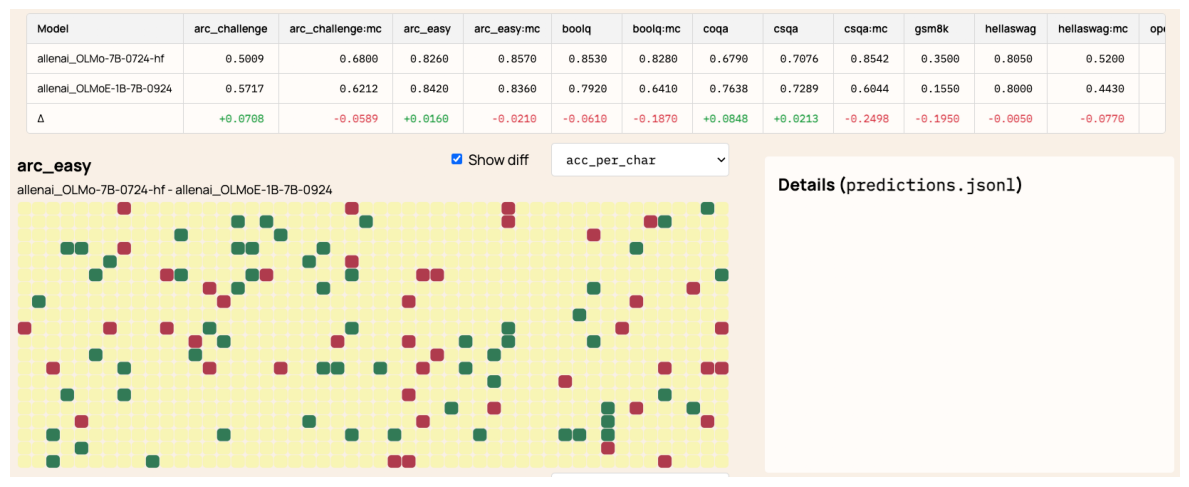

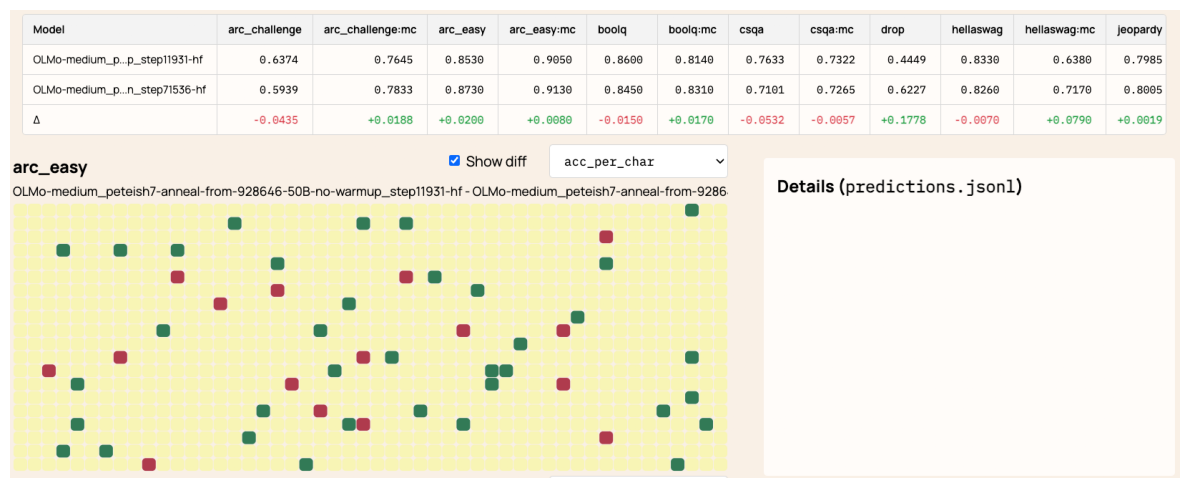

In [207]:
from PIL import Image
import matplotlib.pyplot as plt

def display_image(path, max_width=1200):
    img = Image.open(path)
    plt.figure(figsize=(min(max_width/100, img.width/100), img.height/100))
    plt.imshow(plt.imread(path))
    plt.axis('off')
    plt.tight_layout()
    plt.show()

print('Comparison of metric scores is about the same ~+0.16 vs ~+0.02, but the agreement rate is different:')
print('Example of agreement between models (https://huggingface.co/spaces/allenai/model-diff):')
os.chdir('/Users/dhei/ai2/new-evals/analysis/notebooks')
display_image('assets/model-diff-1.png')
display_image('assets/model-diff-2.png')

### Paired Permutation Test

In [191]:
from dataloader import get_nd_array
from stats import compute_total_variation, compute_significance

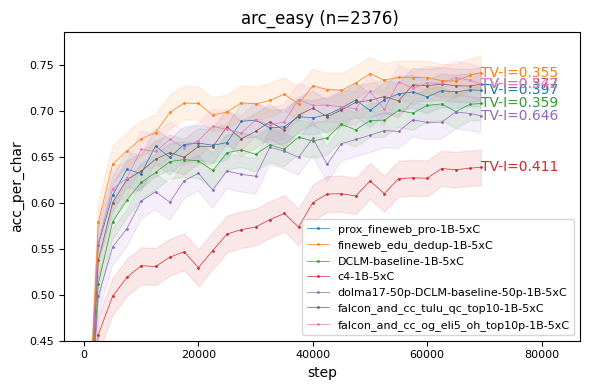

In [192]:
tasks = ['arc_easy']
n_tasks = len(tasks)

fig, axes = plt.subplots(n_tasks, 1, figsize=(6, 4*n_tasks), squeeze=False)

random_colors = [plt.cm.tab10.colors[i] for i in range(len(_MODELS))]

tv_results, _ = compute_total_variation(
    df, 
    tasks=tasks,
    models=_MODELS,
    metric='acc_per_char',
    axes=axes[:, 0],
    color=random_colors
)

axes[0, 0].set_ylim(bottom=0.45)

fig.tight_layout()

Explanation of a paired permutation test:


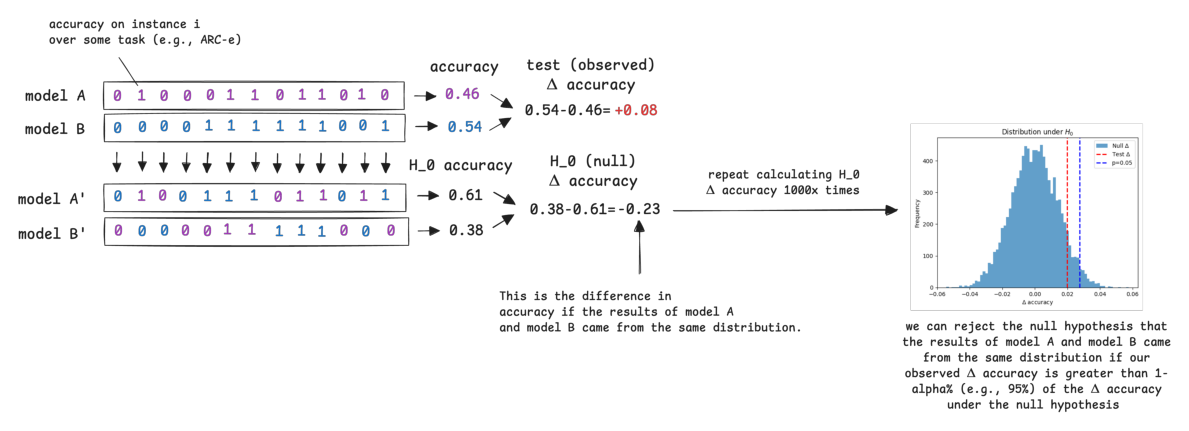

In [193]:
from PIL import Image
import matplotlib.pyplot as plt

def display_image(path, max_width=1200):
    img = Image.open(path)
    plt.figure(figsize=(min(max_width/100, img.width/100), img.height/100))
    plt.imshow(plt.imread(path))
    plt.axis('off')
    plt.tight_layout()
    plt.show()

print('Explanation of a paired permutation test:')
os.chdir('/Users/dhei/ai2/new-evals/analysis/notebooks')
display_image('assets/paired-permutation-test.png')

Comparing model A (falcon_and_cc_og_eli5_oh_top10p-1B-5xC) to model B (falcon_and_cc_tulu_qc_top10-1B-5xC):

Model A score: 0.7294
Model B score: 0.7290
Observed score difference (Model A - Model B): 0.0004

Contingency Table:
              M2 Correct M2 Incorrect
M1 Correct        0.6688       0.0606
M1 Incorrect      0.0602       0.2104

Agreement Rate: 0.8792

Critical value: 0.0122


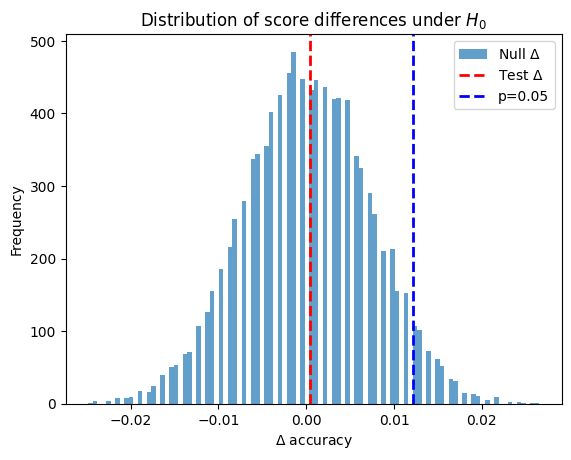

In [196]:
from utils.pce import compute_deltas

def run_model_comparison(task):
    mixes, scores = get_nd_array(df, 'model', model=_MODELS, task=task, metric='acc_per_char', step='max', sorted=True)

    null_deltas, test_deltas, _ = compute_deltas(scores, num_permutations=10_000)

    i, j = 1, 2

    print(f'Comparing model A ({mixes[i]}) to model B ({mixes[j]}):\n')

    plt.hist(null_deltas[i, j], bins=100, alpha=0.7, label=r'Null $\Delta$')
    plt.axvline(test_deltas[i, j], color='red', linestyle='--', linewidth=2, label=r'Test $\Delta$')

    # Get contingency table
    A, B = scores[i], scores[j]
    table = np.array([[np.sum((A == 1) & (B == 1)), np.sum((A == 1) & (B == 0))],
                    [np.sum((A == 0) & (B == 1)), np.sum((A == 0) & (B == 0))]]) / len(A)
    agreement_rate = table[0, 0] + table[1, 1]

    model_1_score = np.mean(A)
    model_2_score = np.mean(B)
    score_difference = model_1_score - model_2_score

    print(f'Model A score: {model_1_score:.4f}')
    print(f'Model B score: {model_2_score:.4f}')
    print(f'Observed score difference (Model A - Model B): {score_difference:.4f}')

    print('\nContingency Table:')
    print(f'              M2 Correct M2 Incorrect')
    print(f'M1 Correct  {table[0, 0]:12.4f} {table[0, 1]:12.4f}')
    print(f'M1 Incorrect{table[1, 0]:12.4f} {table[1, 1]:12.4f}')
    print(f'\nAgreement Rate: {agreement_rate:.4f}')

    p_threshold = 0.05
    critical_value = np.percentile(null_deltas[i, j], [(p_threshold) * 100, (1 - p_threshold) * 100])
    plt.axvline(critical_value[1], color='blue', linestyle='--', linewidth=2, label='p=0.05')

    print(f'\nCritical value: {critical_value[1]:.4f}')

    plt.xlabel(r'$\Delta$ accuracy')
    plt.ylabel('Frequency')
    plt.title(r'Distribution of score differences under $H_0$')
    plt.legend()
    plt.show()

run_model_comparison('arc_easy')

Computing pairwise comparisons:   0%|          | 0/1 [00:00<?, ?it/s]

Computing pairwise comparisons: 100%|██████████| 1/1 [00:00<00:00,  2.13it/s]


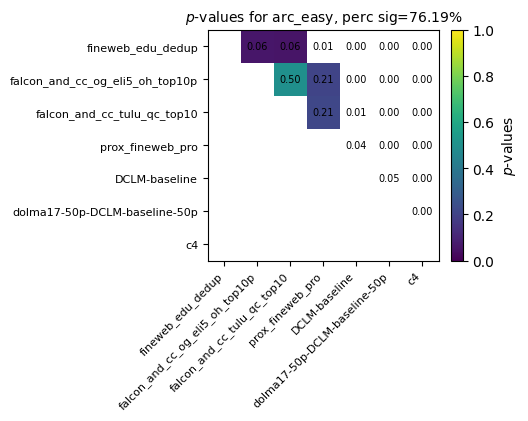

In [200]:
fig, axes = plt.subplots(1, 1, figsize=(4, 3), squeeze=False)

sig_results, _, ax = compute_significance(
    df, 
    models=_MODELS, 
    metric='acc_per_char', 
    tasks=tasks, 
    alpha=0.05,
    do_plot=axes[0][0]
)

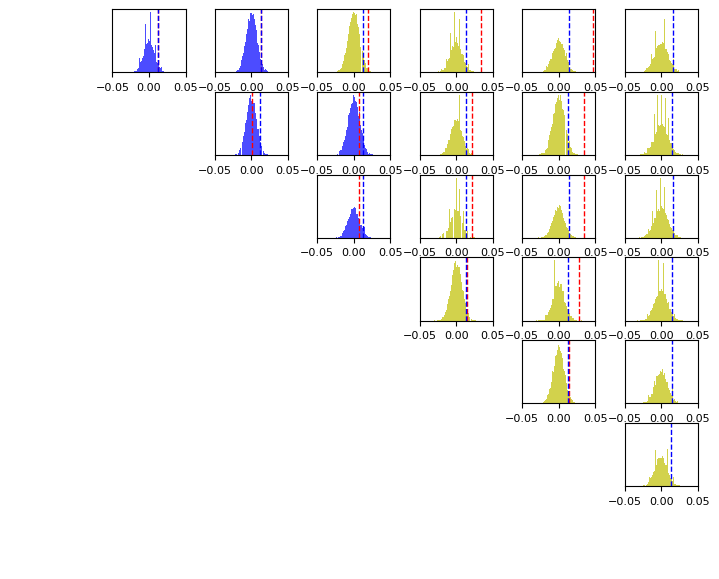

In [214]:
import matplotlib.pyplot as plt
import numpy as np
from utils.pce import compute_deltas

def plot_comparison_dist(task):
    mixes, scores = get_nd_array(df, 'mix', model=_MODELS, task=task, metric='acc_per_char', step='max', sorted=True)

    null_deltas, test_deltas, p_vales = compute_deltas(scores, num_permutations=10000)

    # Plot all p-values
    p_threshold = 0.05
    fig, axes = plt.subplots(null_deltas.shape[0], null_deltas.shape[1], figsize=(len(_MODELS), 0.8*len(_MODELS))) # 20, 15

    for i in range(null_deltas.shape[0]):
        for j in range(null_deltas.shape[1]):
            if i < j:
                null_delta = null_deltas[i, j]
                test_delta = test_deltas[i, j]
                
                critical_value = np.percentile(null_delta, [(p_threshold) * 100, (1 - p_threshold) * 100])
                color = 'y' if test_delta > critical_value[1]+0.0001 else 'b'
                
                axes[i, j].hist(null_delta, bins=70, alpha=0.7, label=r'Null $\Delta$', color=color)
                axes[i, j].axvline(test_delta, color='red', linestyle='--', linewidth=1, label=r'Test $\Delta$')
                axes[i, j].axvline(critical_value[1], color='blue', linestyle='--', linewidth=1, label=r'p=0.05')
                axes[i, j].set_xlim(-0.05, 0.05)
                axes[i, j].tick_params(axis='both', labelsize=8)
                axes[i, j].set_yticks([])
            else:
                axes[i, j].axis('off')

    # plt.subplots_adjust(wspace=0, hspace=0)
    # plt.tight_layout(pad=0)
    # plt.show()

    plt.subplots_adjust(wspace=0, hspace=0)
    plt.tight_layout(pad=0)
    plt.show()

plot_comparison_dist('arc_easy')

### Comparing Results on More Tasks

Computing pairwise comparisons: 100%|██████████| 1/1 [00:00<00:00,  1.28it/s]


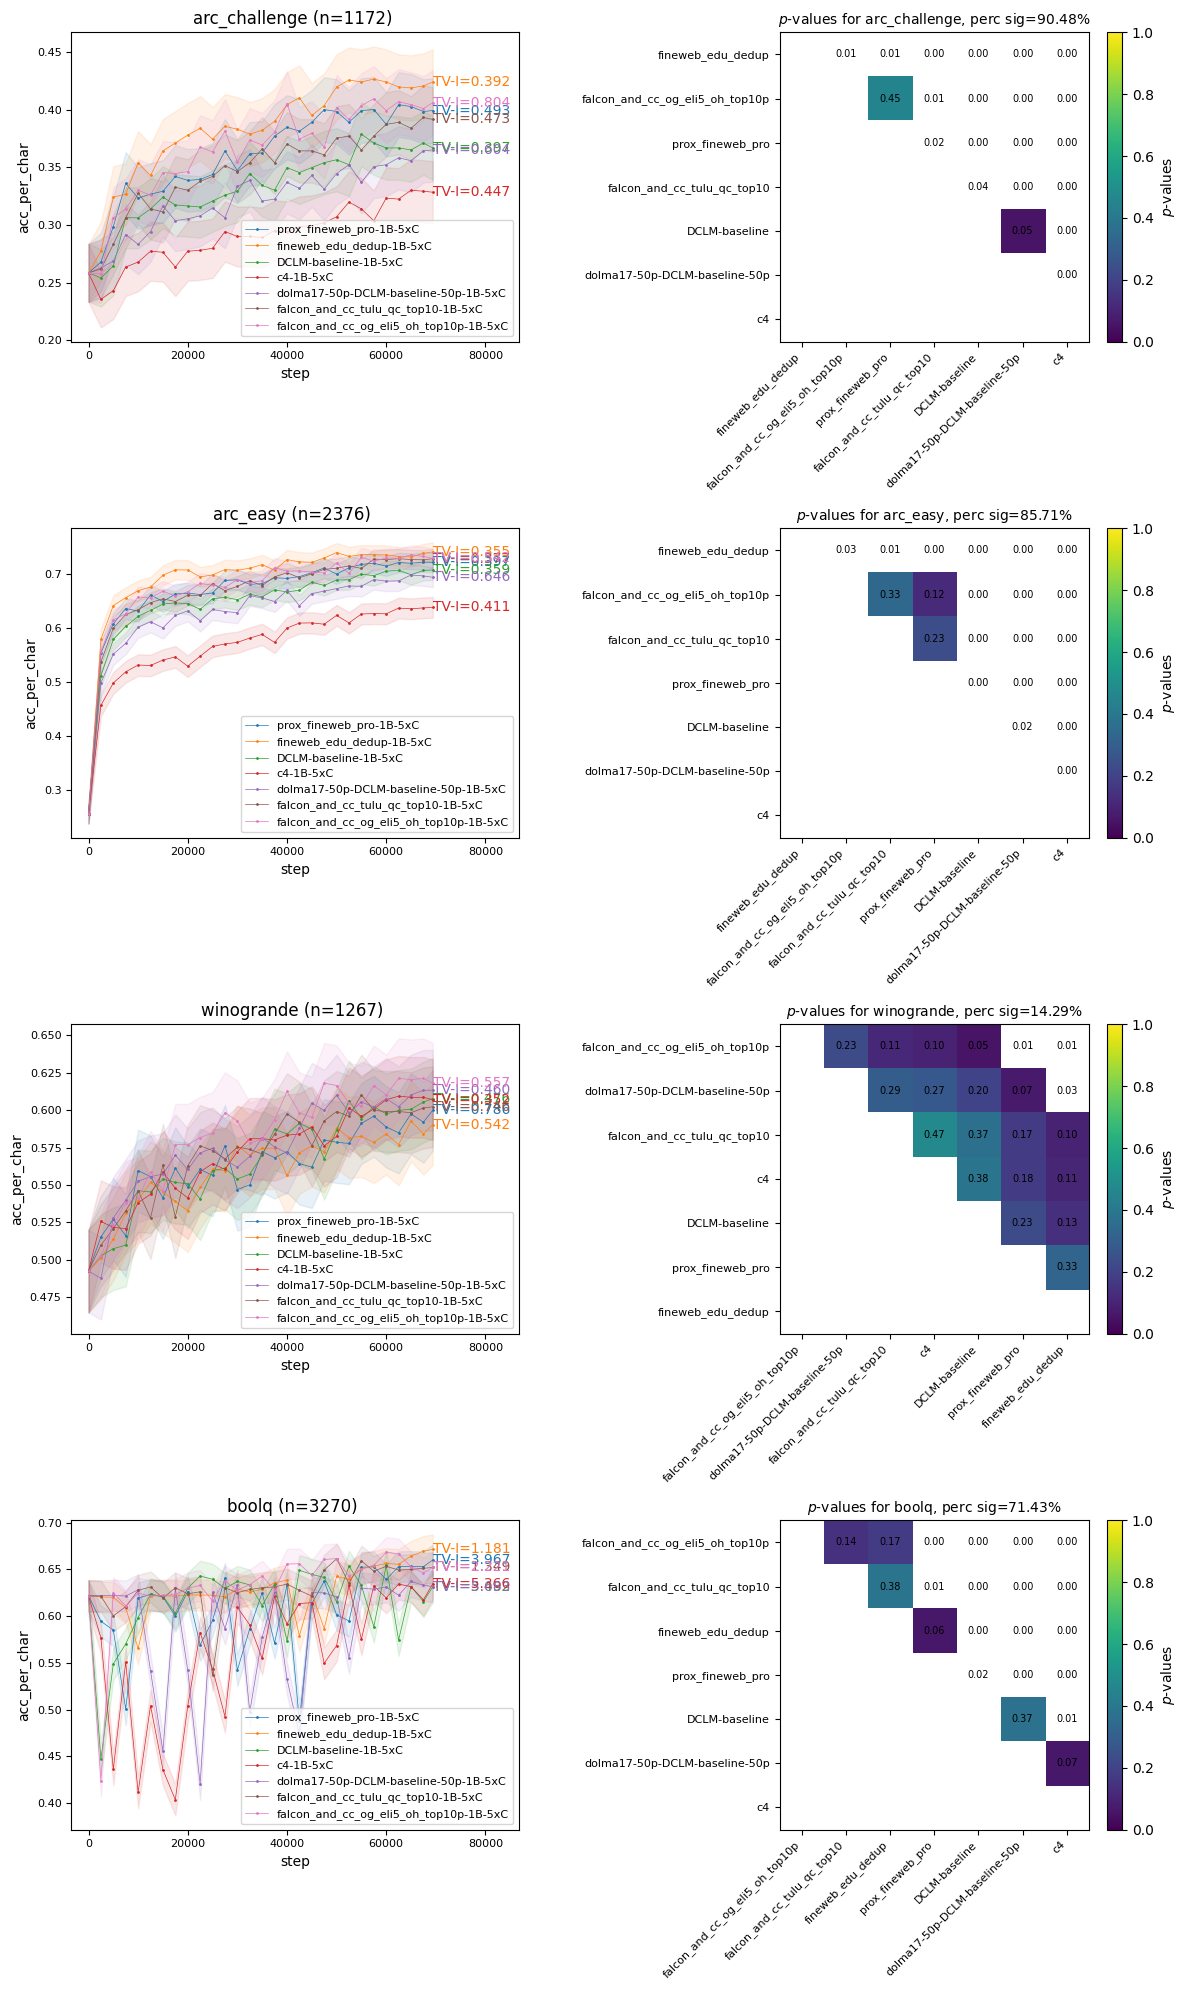

In [203]:
tasks = ['arc_challenge', 'arc_easy', 'winogrande', 'boolq']
n_tasks = len(tasks)

fig, axes = plt.subplots(n_tasks, 2, figsize=(6*2, 5*n_tasks), squeeze=False)

random_colors = [plt.cm.tab10.colors[i] for i in range(len(_MODELS))]

tv_results, _ = compute_total_variation(
    df, 
    tasks=tasks,
    models=_MODELS,
    metric='acc_per_char',
    axes=axes[:, 0],
    color=random_colors
)

for i, task in enumerate(tasks):
    sig_results, _, ax = compute_significance(
        df, 
        models=_MODELS, 
        metric='acc_per_char', 
        tasks=[task], 
        alpha=0.05,
        do_plot=axes[i][1],
        last_n=10
    )

fig.tight_layout()